In [1]:
import mne
import numpy as np

In [2]:
close_raw = mne.io.read_raw_bdf("../dataset/close_UnicornPreprocessedDataRecorder_15_07_2026_16_09_47.bdf", preload=True)
open_raw = mne.io.read_raw_bdf("../dataset/open_UnicornPreprocessedDataRecorder_15_07_2026_16_04_18.bdf", preload=True)

Extracting BDF parameters from ../dataset/close_UnicornPreprocessedDataRecorder_15_07_2026_16_09_47.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 76446  =      0.000 ...   305.784 secs...
Extracting BDF parameters from ../dataset/open_UnicornPreprocessedDataRecorder_15_07_2026_16_04_18.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 76162  =      0.000 ...   304.648 secs...


In [3]:
close_raw.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)

open_raw.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)
close_raw.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
open_raw.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})

C:\Users\akila\AppData\Local\Temp\ipykernel_29560\610431433.py:26: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  close_raw.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
C:\Users\akila\AppData\Local\Temp\ipykernel_29560\610431433.py:27: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  open_raw.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})


<RawBDF | open_UnicornPreprocessedDataRecorder_15_07_2026_16_04_18.bdf, 14 x 76163 (304.7 s), ~8.1 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\akila\AppData\Local\Temp\ipykernel_29560\4159356904.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  close_raw.plot_psd(fmin=0.5, fmax=20)
c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


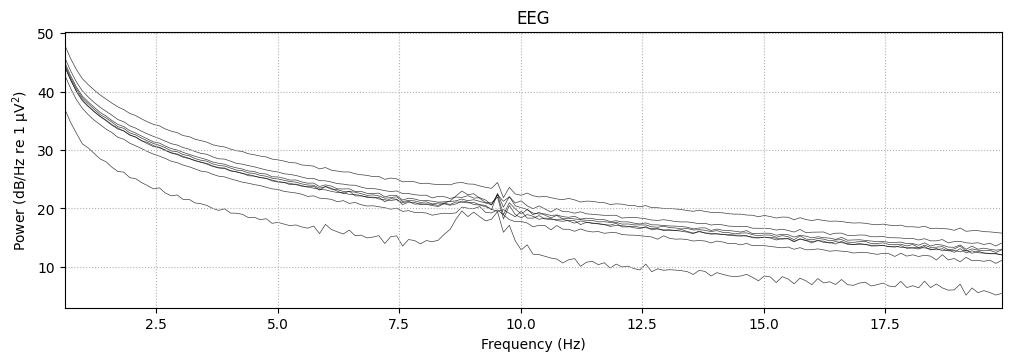

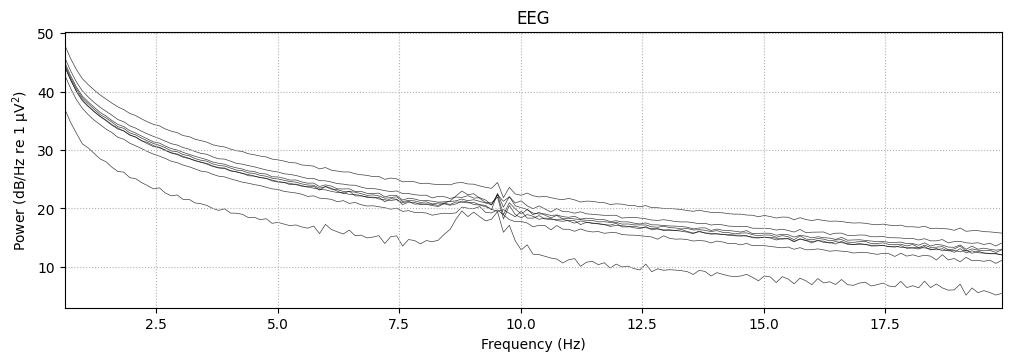

In [4]:
close_raw.plot_psd(fmin=0.5, fmax=20)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\akila\AppData\Local\Temp\ipykernel_29560\3275204484.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  open_raw.plot_psd(fmin=0, fmax=20)
c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


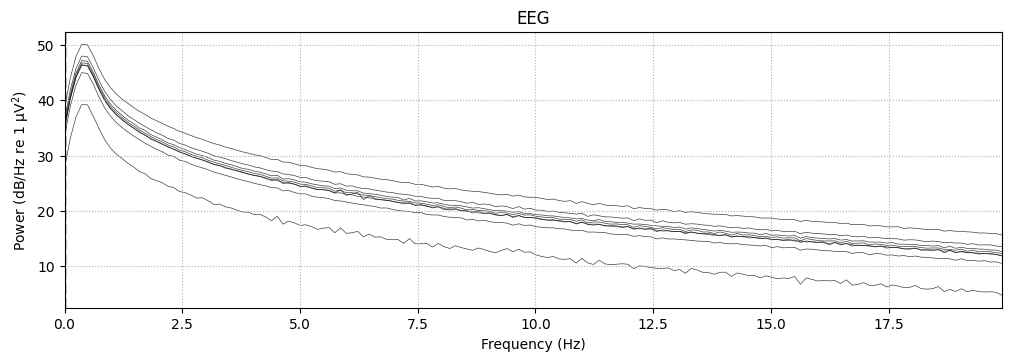

In [5]:
open_raw.plot_psd(fmin=0, fmax=20)

In [6]:
open_raw.set_montage("standard_1005")
close_raw.set_montage("standard_1005")

<RawBDF | close_UnicornPreprocessedDataRecorder_15_07_2026_16_09_47.bdf, 14 x 76447 (305.8 s), ~8.2 MiB, data loaded>

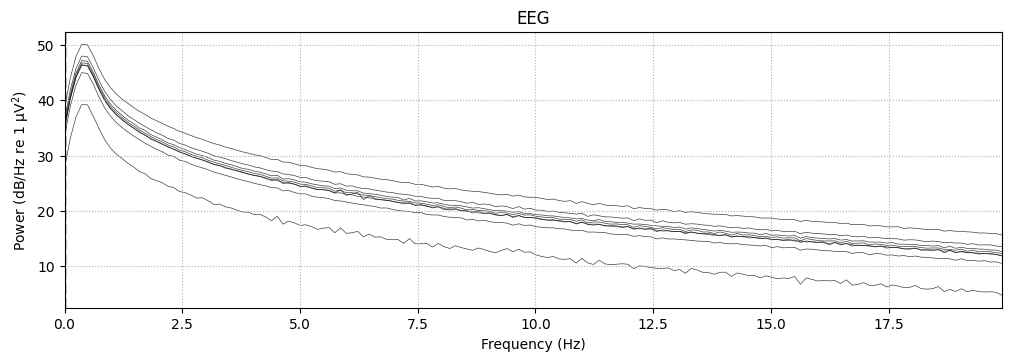

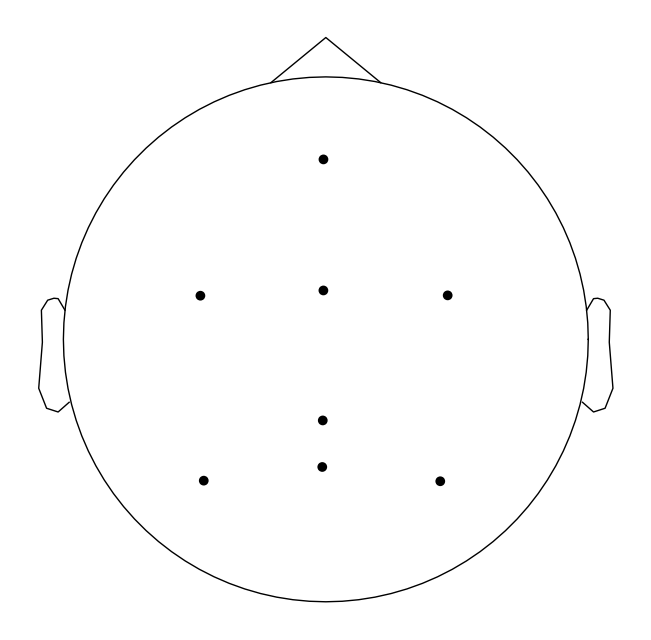

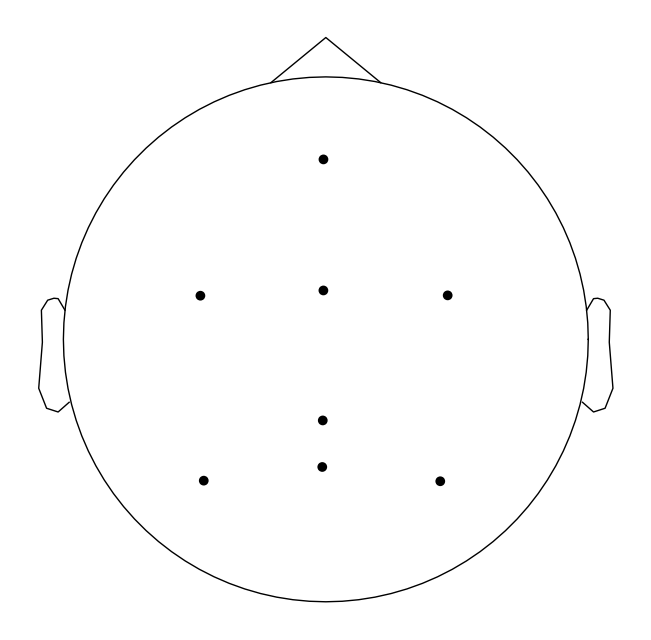

In [7]:
open_raw.plot_sensors()

Using matplotlib as 2D backend.


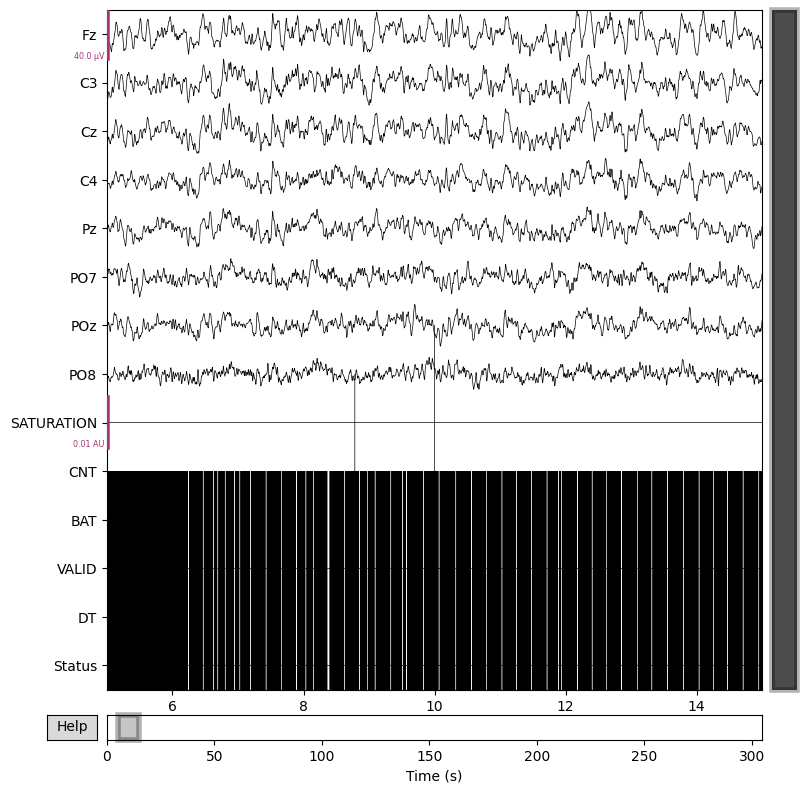

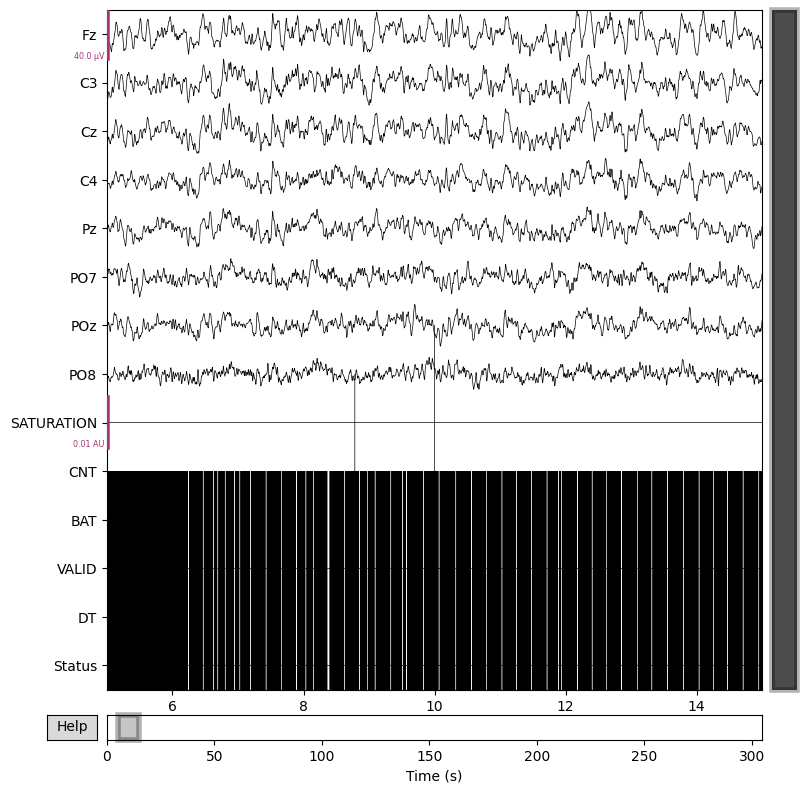

In [8]:
open_raw.plot(start=5)

Applying baseline correction (mode: logratio)


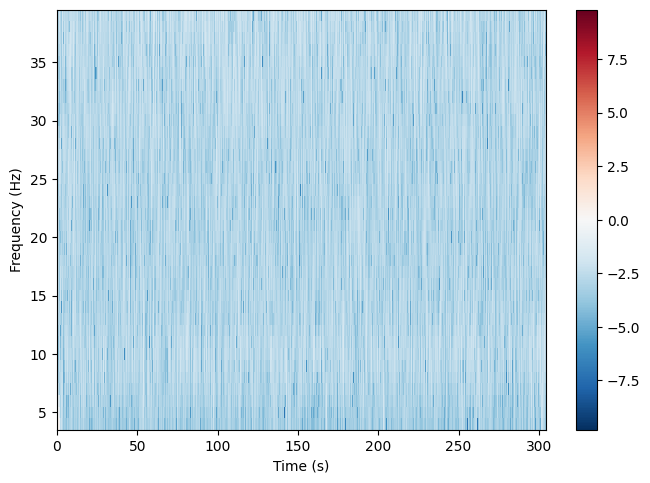

Applying baseline correction (mode: logratio)


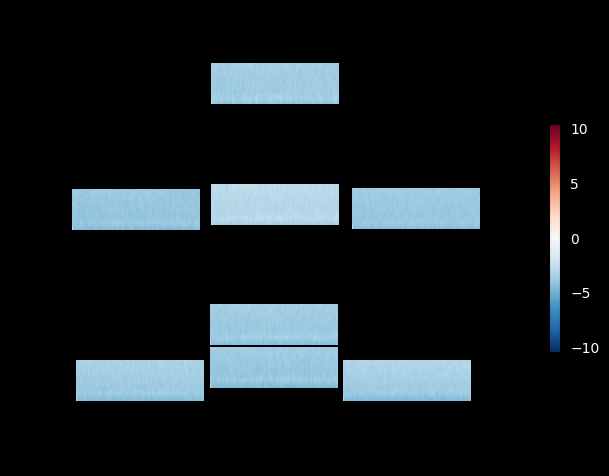

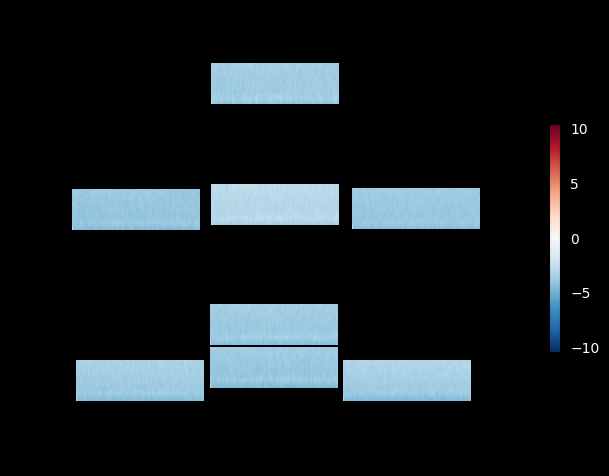

In [9]:
freqs = np.arange(4, 40, 1)  
n_cycles = freqs / 2.0       

open_tfr = open_raw.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    decim=3,          
    picks="eeg"        
)

open_tfr.plot(picks="Cz", baseline=(None, None), mode="logratio")

open_tfr.plot_topo(baseline=(None, None), mode="logratio")

Applying baseline correction (mode: logratio)


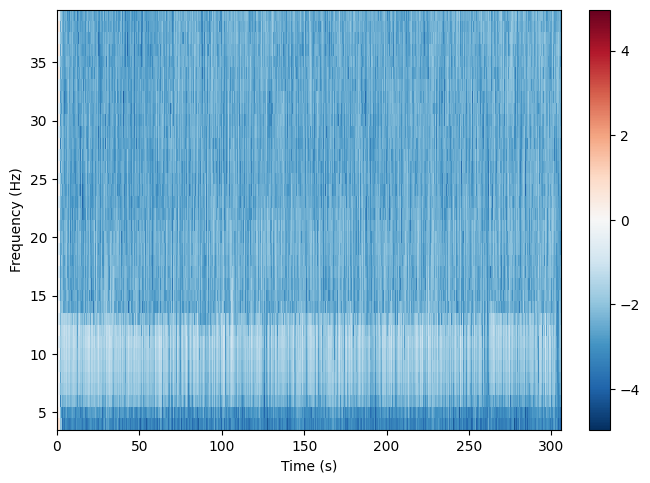

Applying baseline correction (mode: logratio)


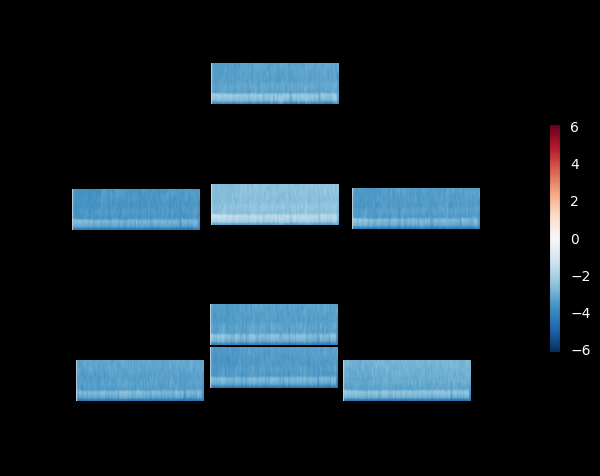

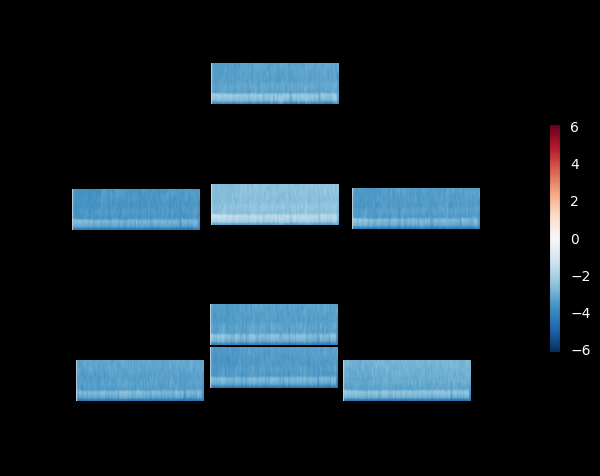

In [10]:
freqs = np.arange(4, 40, 1)  
n_cycles = freqs / 2.0       

close_tfr = close_raw.compute_tfr(
    method="multitaper",
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    decim=3,          
    picks="eeg"        
) * 2

close_tfr.plot(picks="Cz", baseline=(None, None), mode="logratio")

close_tfr.plot_topo(baseline=(None, None), mode="logratio")

In [11]:

open_epochs = mne.make_fixed_length_epochs(
    open_raw,
    duration=2.0,      # 2-second epochs
    overlap=0.0,        # no overlap; set e.g. 1.0 for 50% overlap
    preload=True
)

print(open_epochs)
print(f"Number of epochs: {len(open_epochs)}")
print(f"Epoch duration: {open_epochs.tmax - open_epochs.tmin} s")

Not setting metadata
152 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 152 events and 500 original time points ...
0 bad epochs dropped
<Epochs | 152 events (all good), 0 – 1.996 s (baseline off), ~8.1 MiB, data loaded,
 '1': 152>
Number of epochs: 152
Epoch duration: 1.996 s


In [12]:

close_epochs = mne.make_fixed_length_epochs(
    close_raw,
    duration=1.0,      # 2-second epochs
    overlap=0.0,        # no overlap; set e.g. 1.0 for 50% overlap
    preload=True
)

print(close_epochs)
print(f"Number of epochs: {len(open_epochs)}")
print(f"Epoch duration: {open_epochs.tmax - open_epochs.tmin} s")

Not setting metadata
305 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 305 events and 250 original time points ...
0 bad epochs dropped
<Epochs | 305 events (all good), 0 – 0.996 s (baseline off), ~8.2 MiB, data loaded,
 '1': 305>
Number of epochs: 152
Epoch duration: 1.996 s


In [13]:
import numpy as np
import pywt

sfreq = open_raw.info['sfreq']          # e.g. 250 Hz
wavelet = 'db4'                    # common choice for EEG; change if you prefer another
max_level = 6                      # decomposition depth — tune based on sfreq

# Get frequency band edges for each node at max_level, ordered by frequency
nyquist = sfreq / 2
n_nodes = 2 ** max_level
band_width = nyquist / n_nodes
band_edges = [(i * band_width, (i + 1) * band_width) for i in range(n_nodes)]

# Find node indices whose band overlaps 7-13 Hz
target_low, target_high = 7, 13
selected_indices = [
    i for i, (lo, hi) in enumerate(band_edges)
    if hi > target_low and lo < target_high
]
print("Selected node freq bands:", [band_edges[i] for i in selected_indices])

# Get epoch data: shape (n_epochs, n_channels, n_times)
data = open_epochs.pick("eeg").get_data()

open_alpha_coeffs = []  # will hold WPT coeffs for the alpha-overlapping nodes

for epoch_data in data:               # loop over epochs
    epoch_ch_coeffs = []
    for ch_data in epoch_data:        # loop over channels
        wp = pywt.WaveletPacket(data=ch_data, wavelet=wavelet,
                                 mode='symmetric', maxlevel=max_level)
        # get nodes in frequency order at max_level
        nodes = wp.get_level(max_level, order='freq')
        # extract coefficients for selected alpha-band nodes
        node_coeffs = [nodes[i].data for i in selected_indices]
        epoch_ch_coeffs.append(node_coeffs)
    open_alpha_coeffs.append(epoch_ch_coeffs)

open_alpha_coeffs = np.array(open_alpha_coeffs)
print("Shape: (n_epochs, n_channels, n_selected_nodes, n_coeffs_per_node)")
print(open_alpha_coeffs.shape)

Selected node freq bands: [(5.859375, 7.8125), (7.8125, 9.765625), (9.765625, 11.71875), (11.71875, 13.671875)]
Shape: (n_epochs, n_channels, n_selected_nodes, n_coeffs_per_node)
(152, 8, 4, 14)


In [14]:
sfreq = close_raw.info['sfreq']          # e.g. 250 Hz
wavelet = 'db4'                    # common choice for EEG; change if you prefer another
max_level = 6                      # decomposition depth — tune based on sfreq

# Get frequency band edges for each node at max_level, ordered by frequency
nyquist = sfreq / 2
n_nodes = 2 ** max_level
band_width = nyquist / n_nodes
band_edges = [(i * band_width, (i + 1) * band_width) for i in range(n_nodes)]

# Find node indices whose band overlaps 7-13 Hz
target_low, target_high = 7, 13
selected_indices = [
    i for i, (lo, hi) in enumerate(band_edges)
    if hi > target_low and lo < target_high
]
print("Selected node freq bands:", [band_edges[i] for i in selected_indices])

# Get epoch data: shape (n_epochs, n_channels, n_times)
data = close_epochs.pick("eeg").get_data()

close_alpha_coeffs = []  # will hold WPT coeffs for the alpha-overlapping nodes

for epoch_data in data:               # loop over epochs
    epoch_ch_coeffs = []
    for ch_data in epoch_data:        # loop over channels
        wp = pywt.WaveletPacket(data=ch_data, wavelet=wavelet,
                                 mode='symmetric', maxlevel=max_level)
        # get nodes in frequency order at max_level
        nodes = wp.get_level(max_level, order='freq')
        # extract coefficients for selected alpha-band nodes
        node_coeffs = [nodes[i].data for i in selected_indices]
        epoch_ch_coeffs.append(node_coeffs)
    close_alpha_coeffs.append(epoch_ch_coeffs)

close_alpha_coeffs = np.array(close_alpha_coeffs)
print("Shape: (n_epochs, n_channels, n_selected_nodes, n_coeffs_per_node)")
print(close_alpha_coeffs.shape)

Selected node freq bands: [(5.859375, 7.8125), (7.8125, 9.765625), (9.765625, 11.71875), (11.71875, 13.671875)]
Shape: (n_epochs, n_channels, n_selected_nodes, n_coeffs_per_node)
(305, 8, 4, 10)


In [15]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

def extract_features(coeff_array):
    # coeff_array shape: (n_epochs, n_channels, n_nodes, n_coeffs)
    energy = np.sum(coeff_array ** 2, axis=-1)      # sum over coeffs -> (n_epochs, ch, nodes)
    log_energy = np.log(energy + 1e-12)              # log for stability
    features = log_energy.reshape(log_energy.shape[0], -1)  # flatten -> (n_epochs, ch*nodes)
    return features

X_close = extract_features(close_alpha_coeffs)   # (152, 32)
X_open  = extract_features(open_alpha_coeffs)    # (152, 32)

# --- 2. Combine and label ---
X = np.vstack([X_close, X_open])
y = np.hstack([np.ones(len(X_close)), np.zeros(len(X_open))])  # 1=closed, 0=open

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True
)

# --- 4. Classifiers to compare ---
classifiers = {
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0)),
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    print(f"{name}: CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

# --- 5. Fit best model on train set, evaluate on held-out test set ---
best_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0))
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

print("\nTest set performance:")
print(classification_report(y_test, y_pred, target_names=['open', 'closed']))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Feature matrix shape: (457, 32)
Labels shape: (457,)
SVM (RBF): CV accuracy = 0.978 ± 0.007
LDA: CV accuracy = 0.974 ± 0.018
Random Forest: CV accuracy = 0.983 ± 0.011

Test set performance:
              precision    recall  f1-score   support

        open       0.94      1.00      0.97        31
      closed       1.00      0.97      0.98        61

    accuracy                           0.98        92
   macro avg       0.97      0.98      0.98        92
weighted avg       0.98      0.98      0.98        92

Confusion matrix:
 [[31  0]
 [ 2 59]]


Explained variance ratio (first 5 PCs): [0.63990028 0.07912938 0.04165701 0.03726257 0.03036701]
Cumulative variance (first 5 PCs): [0.63990028 0.71902967 0.76068668 0.79794925 0.82831627]


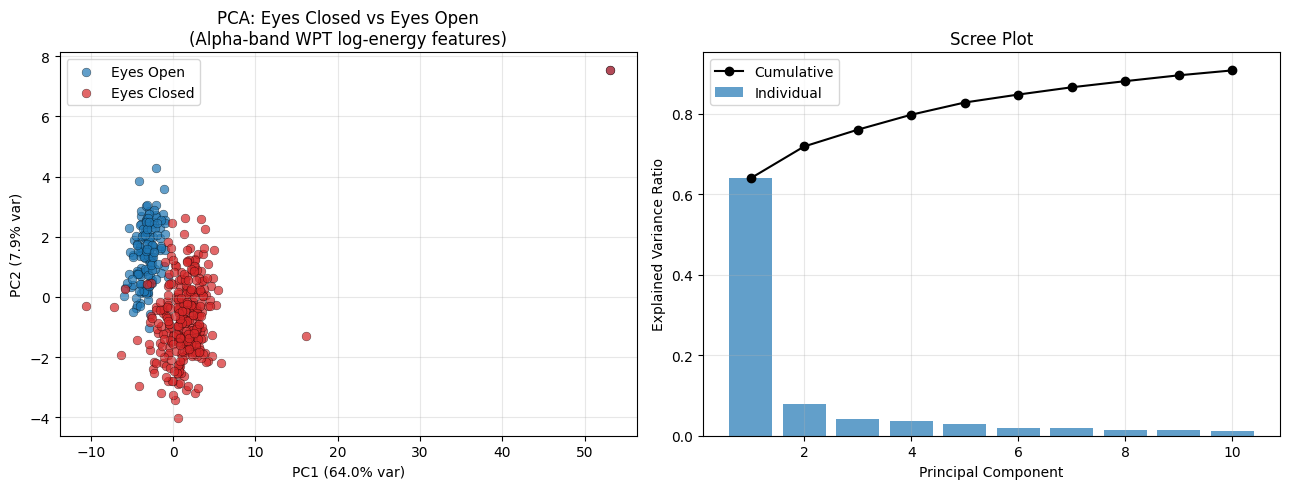

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. Standardize features (important before PCA since features are on different scales) ---
X_scaled = StandardScaler().fit_transform(X)

# --- 2. Fit PCA ---
pca = PCA(n_components=min(10, X.shape[1]))  # keep up to 10 PCs for scree plot
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio (first 5 PCs):", pca.explained_variance_ratio_[:5])
print("Cumulative variance (first 5 PCs):", np.cumsum(pca.explained_variance_ratio_)[:5])

# --- 3. Plot: 2D PCA scatter + scree plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter of PC1 vs PC2, colored by class
colors = {0: 'tab:blue', 1: 'tab:red'}
labels_map = {0: 'Eyes Open', 1: 'Eyes Closed'}

for label in [0, 1]:
    mask = y == label
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[label], label=labels_map[label],
        alpha=0.7, edgecolor='k', linewidth=0.3, s=40
    )

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('PCA: Eyes Closed vs Eyes Open\n(Alpha-band WPT log-energy features)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scree plot
n_pcs = len(pca.explained_variance_ratio_)
axes[1].bar(range(1, n_pcs + 1), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[1].plot(range(1, n_pcs + 1), np.cumsum(pca.explained_variance_ratio_),
             marker='o', color='black', label='Cumulative')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_alpha_eeg.png', dpi=150)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --- 0. Build readable feature names: channel x node ---
ch_names = open_epochs.copy().pick('eeg').ch_names  # 8 channel names
node_bands = ["5.9-7.8Hz", "7.8-9.8Hz", "9.8-11.7Hz", "11.7-13.7Hz"]  # your 4 selected nodes

feature_names = [f"{ch}_{band}" for ch in ch_names for band in node_bands]
assert len(feature_names) == X.shape[1]  # should be 32

# --- 1. Random Forest built-in importance (mean decrease in impurity) ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
rf_importance = rf.feature_importances_

# --- 2. Permutation importance (more reliable, works for any model) ---
perm_result = permutation_importance(rf, X, y, n_repeats=30, random_state=42, scoring='accuracy')
perm_importance = perm_result.importances_mean

# --- 3. LDA coefficients (magnitude = discriminative weight, sign = direction) ---
lda_pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda_pipe.fit(X, y)
lda_coef = lda_pipe.named_steps['lineardiscriminantanalysis'].coef_[0]

# --- 4. Combine into a sorted summary table ---
import pandas as pd
importance_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_importance,
    'perm_importance': perm_importance,
    'lda_coef': lda_coef,
    'lda_abs_coef': np.abs(lda_coef)
}).sort_values('perm_importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

# --- 5. Plot top 15 features by permutation importance ---
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features['feature'][::-1], top_features['perm_importance'][::-1], color='teal', alpha=0.8)
ax.set_xlabel('Permutation Importance (accuracy drop)')
ax.set_title('Top 15 Features: Channel x Alpha Sub-band')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

RF CV accuracy: 0.983 ± 0.011
       feature  rf_importance  perm_importance  perm_std  mean_closed  mean_open  closed_minus_open
 PO8_7.8-9.8Hz       0.209563         0.126988  0.010860   -18.542240 -20.974502           2.432261
 PO8_5.9-7.8Hz       0.080590         0.001605  0.000968   -19.394100 -20.928254           1.534154
 POz_7.8-9.8Hz       0.091714         0.000948  0.001084   -18.622687 -20.310003           1.687316
  Fz_5.9-7.8Hz       0.002235         0.000000  0.000000   -18.348250 -19.067800           0.719550
  C3_5.9-7.8Hz       0.002283         0.000000  0.000000   -18.807673 -19.517214           0.709541
  Fz_7.8-9.8Hz       0.066085         0.000000  0.000000   -17.795579 -19.585357           1.789779
 Fz_9.8-11.7Hz       0.002893         0.000000  0.000000   -19.907728 -19.999777           0.092049
Fz_11.7-13.7Hz       0.019451         0.000000  0.000000   -19.890666 -21.110983           1.220317
  Cz_5.9-7.8Hz       0.007062         0.000000  0.000000   -18.619371 

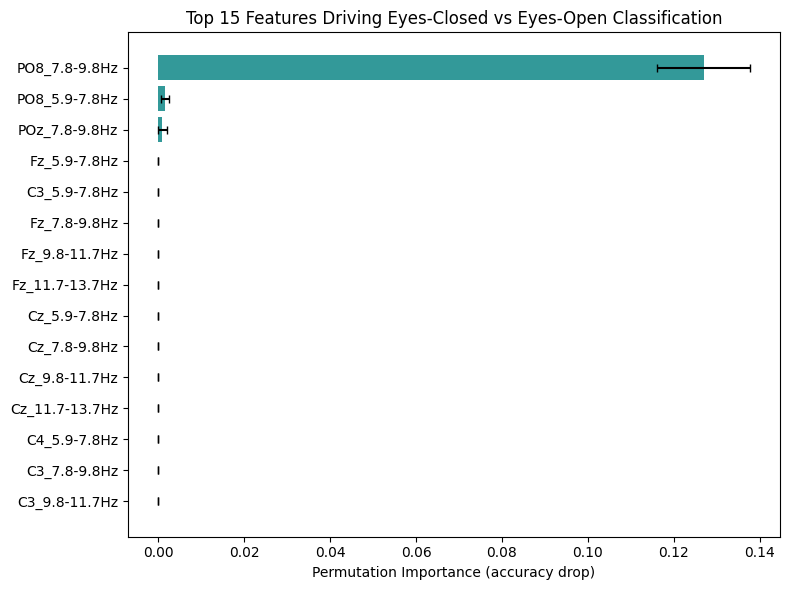

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- 1. Labels derived from the two epoch objects (order-matched to your feature stacking) ---
n_close = len(close_epochs)
n_open  = len(open_epochs)

y_close = np.ones(n_close)     # 1 = eyes closed
y_open  = np.zeros(n_open)     # 0 = eyes open
y = np.hstack([y_close, y_open])

# --- 2. Feature matrix (log-energy per channel x node), same order as y ---
def extract_features(coeff_array):
    energy = np.sum(coeff_array ** 2, axis=-1)     # (n_epochs, ch, nodes)
    log_energy = np.log(energy + 1e-12)
    return log_energy.reshape(log_energy.shape[0], -1)

X_close = extract_features(close_alpha_coeffs)
X_open  = extract_features(open_alpha_coeffs)
X = np.vstack([X_close, X_open])

assert X.shape[0] == y.shape[0], "Mismatch between features and labels!"

# --- 3. Readable feature names: channel x alpha sub-band ---
ch_names = close_epochs.copy().pick('eeg').ch_names   # 8 channel names
node_bands = ["5.9-7.8Hz", "7.8-9.8Hz", "9.8-11.7Hz", "11.7-13.7Hz"]
feature_names = [f"{ch}_{band}" for ch in ch_names for band in node_bands]
assert len(feature_names) == X.shape[1]

# --- 4. Train RF (with quick CV sanity check) ---
rf = RandomForestClassifier(n_estimators=300, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f"RF CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

rf.fit(X, y)

# --- 5. Built-in RF importance ---
rf_importance = rf.feature_importances_

# --- 6. Permutation importance (more trustworthy) ---
perm_result = permutation_importance(rf, X, y, n_repeats=30, random_state=42, scoring='accuracy')
perm_importance = perm_result.importances_mean
perm_std = perm_result.importances_std

# --- 7. Per-class mean feature values (shows WHICH class drives each top feature) ---
mean_closed = X[y == 1].mean(axis=0)
mean_open   = X[y == 0].mean(axis=0)

# --- 8. Combine into summary table ---
importance_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_importance,
    'perm_importance': perm_importance,
    'perm_std': perm_std,
    'mean_closed': mean_closed,
    'mean_open': mean_open,
    'closed_minus_open': mean_closed - mean_open
}).sort_values('perm_importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

# --- 9. Plot top 15 by permutation importance, with error bars ---
top_n = 15
top = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top['feature'], top['perm_importance'], xerr=top['perm_std'],
        color='teal', alpha=0.8, capsize=3)
ax.set_xlabel('Permutation Importance (accuracy drop)')
ax.set_title('Top 15 Features Driving Eyes-Closed vs Eyes-Open Classification')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

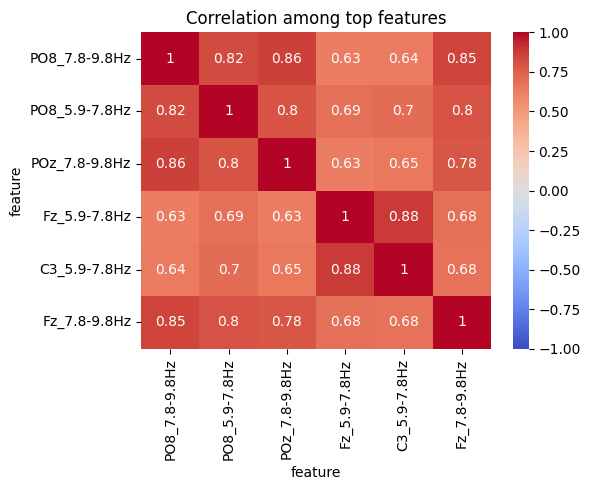

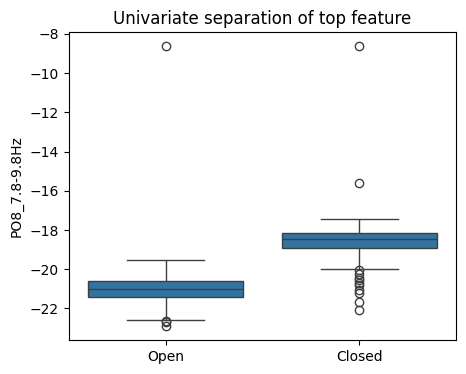

Accuracy using ONLY PO8_7.8-9.8Hz: 0.950


In [ ]:
import seaborn as sns

# 1. Check correlation among top features to see if "winner-take-all" is the likely cause
top_feats_idx = importance_df.head(6).index
corr_matrix = pd.DataFrame(X[:, top_feats_idx], columns=importance_df.head(6)['feature']).corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation among top features')
plt.tight_layout()
plt.show()

# 2. Check if PO8_7.8-9.8Hz alone separates the classes almost perfectly (univariate)
top_feature_idx = importance_df.index[0]
plt.figure(figsize=(5,4))
sns.boxplot(x=y, y=X[:, top_feature_idx])
plt.xticks([0,1], ['Open', 'Closed'])
plt.ylabel(importance_df.iloc[0]['feature'])
plt.title('Univariate separation of top feature')
plt.show()

# 3. Single-feature classification accuracy (sanity check magnitude of effect)
from sklearn.model_selection import cross_val_score
single_feat_acc = cross_val_score(RandomForestClassifier(random_state=42),
                                   X[:, [top_feature_idx]], y, cv=5).mean()
print(f"Accuracy using ONLY {importance_df.iloc[0]['feature']}: {single_feat_acc:.3f}")

Dropping 4 features: ['PO8_5.9-7.8Hz', 'PO8_7.8-9.8Hz', 'PO8_9.8-11.7Hz', 'PO8_11.7-13.7Hz']
New feature matrix shape: (457, 28)
RF CV accuracy (without PO8): 0.963 ± 0.018
       feature  rf_importance  perm_importance  perm_std  mean_closed  mean_open  closed_minus_open
 POz_7.8-9.8Hz       0.140213         0.003939  0.001732   -18.622687 -20.310003           1.687316
 PO7_7.8-9.8Hz       0.071713         0.003501  0.001751   -18.830020 -20.443538           1.613518
  C3_7.8-9.8Hz       0.119909         0.001459  0.001032   -18.143388 -19.773152           1.629764
PO7_9.8-11.7Hz       0.015468         0.000438  0.000875   -20.851364 -20.466679          -0.384684
Fz_11.7-13.7Hz       0.016142         0.000000  0.000000   -19.890666 -21.110983           1.220317
  C3_5.9-7.8Hz       0.005051         0.000000  0.000000   -18.807673 -19.517214           0.709541
 C3_9.8-11.7Hz       0.007475         0.000000  0.000000   -20.029074 -19.920747          -0.108327
C3_11.7-13.7Hz       0.0098

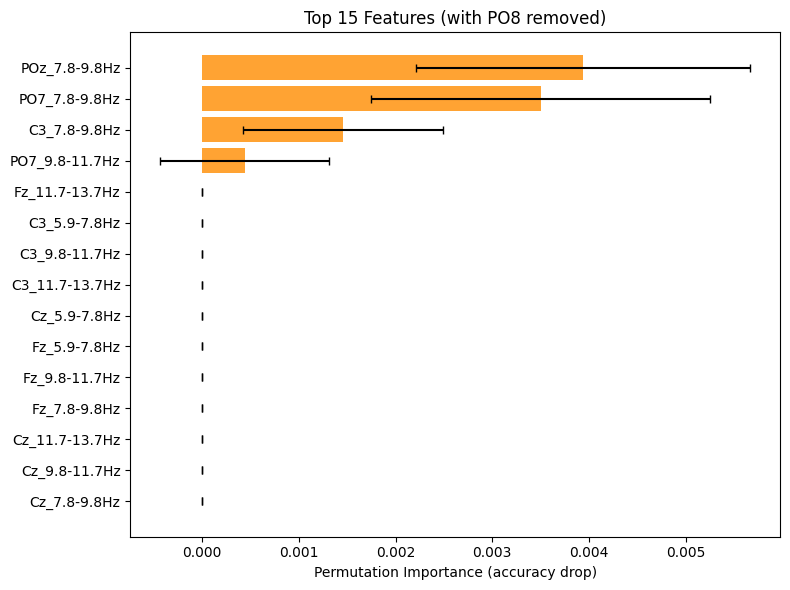

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- 1. Identify which feature columns belong to the channel you want to drop ---
drop_channel = "PO8"

keep_indices = [i for i, name in enumerate(feature_names) if not name.startswith(drop_channel + "_")]
dropped_indices = [i for i, name in enumerate(feature_names) if name.startswith(drop_channel + "_")]

print(f"Dropping {len(dropped_indices)} features:", [feature_names[i] for i in dropped_indices])

# --- 2. Build reduced feature matrix and names ---
X_reduced = X[:, keep_indices]
feature_names_reduced = [feature_names[i] for i in keep_indices]

print("New feature matrix shape:", X_reduced.shape)

# --- 3. Re-run CV sanity check on reduced features ---
rf_reduced = RandomForestClassifier(n_estimators=300, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_reduced, X_reduced, y, cv=cv, scoring='accuracy')
print(f"RF CV accuracy (without {drop_channel}): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

rf_reduced.fit(X_reduced, y)

# --- 4. Recompute importances ---
rf_importance_reduced = rf_reduced.feature_importances_

perm_result_reduced = permutation_importance(
    rf_reduced, X_reduced, y, n_repeats=30, random_state=42, scoring='accuracy'
)
perm_importance_reduced = perm_result_reduced.importances_mean
perm_std_reduced = perm_result_reduced.importances_std

# --- 5. Per-class means for the reduced set ---
mean_closed_reduced = X_reduced[y == 1].mean(axis=0)
mean_open_reduced   = X_reduced[y == 0].mean(axis=0)

# --- 6. Summary table ---
importance_df_reduced = pd.DataFrame({
    'feature': feature_names_reduced,
    'rf_importance': rf_importance_reduced,
    'perm_importance': perm_importance_reduced,
    'perm_std': perm_std_reduced,
    'mean_closed': mean_closed_reduced,
    'mean_open': mean_open_reduced,
    'closed_minus_open': mean_closed_reduced - mean_open_reduced
}).sort_values('perm_importance', ascending=False)

print(importance_df_reduced.head(10).to_string(index=False))

# --- 7. Plot top 15 for the reduced feature set ---
top_n = 15
top_reduced = importance_df_reduced.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_reduced['feature'], top_reduced['perm_importance'], xerr=top_reduced['perm_std'],
        color='darkorange', alpha=0.8, capsize=3)
ax.set_xlabel('Permutation Importance (accuracy drop)')
ax.set_title(f'Top 15 Features (with {drop_channel} removed)')
plt.tight_layout()
plt.savefig('feature_importance_no_PO8.png', dpi=150)
plt.show()